# Overall trends across ten public datasets 

In [1]:
import os
from collections import defaultdict
from tqdm import tqdm

from benchmarking.metrics.base_metrics import (
    compute_base_metrics,
    load_all_feature_tables,
)
from benchmarking.metrics.clique import load_clique_metrics
from benchmarking.loader import get_upset_plot_data

from benchmarking.plots import (
    plot_radar_combined,
    plot_individual_radars,
    plot_upset_combined,
    plot_individual_upset,
    plot_precursor_distributions,
    plot_ms2_quality,
    plot_peak_count_distribution,
    plot_sample_missingness,
    plot_clique_metrics,
)

##### Define datasets

In [2]:
base_dir_public = "../data/public_dataset"
public_datasets = [
    "MSV000090327",
    "MSV000091642",
    "MSV000095813",
    "MSV000097967",
    "MSV000097015",
    "MSV000096291",
    "MSV000096189",
    "ST002402",
    "MSV000084402",
    "MTBLS12332",
]

In [3]:
input_dataset_directories = []

for dataset in public_datasets:
    input_dataset_directories.append(os.path.join(base_dir_public, dataset))

len(input_dataset_directories)

10

# Calculating the metrics across tools

In [4]:
# Aggregate metrics across all datasets
combined_metrics = {}

for dataset_path in tqdm(input_dataset_directories):
    try:
        metrics = compute_base_metrics(
            dataset_path,
            similarity_threshold=0.7,
            annotation_subfolder="annotated_spectral_entropy",
        )

        for tool, tool_metrics in metrics.items():
            if tool not in combined_metrics:
                combined_metrics[tool] = defaultdict(int)

            for metric, value in tool_metrics.items():
                combined_metrics[tool][metric] += value

    except Exception as e:
        print(f"Error processing {dataset_path}: {e}")
        continue

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:24<00:00,  2.50s/it]


# Figure 2a: Creating the radar plots

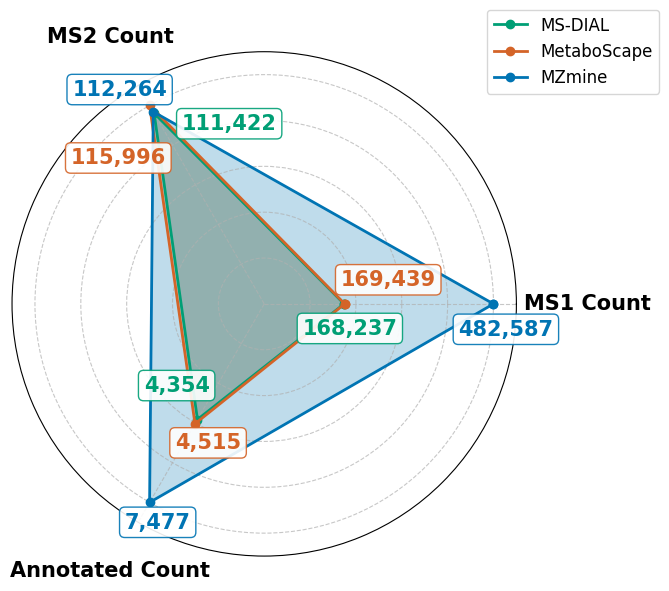

In [5]:
label_offsets = {
    "mzmine": {
        "MS1 Count": (-0.1, -10.0),
        "MS2 Count": (0, 0),
        "Annotated Count": (-0.1, 0.0),
    },
    "msdial": {
        "MS1 Count": (0, -12.0),
        "MS2 Count": (-0.2, -15.0),
        "Annotated Count": (-0.1, -13),
    },
    "metaboscape": {
        "MS1 Count": (0.1, 11.0),
        "MS2 Count": (-0.2, 15.0),
        "Annotated Count": (-0.05, 8.0),
    },
}

plot_radar_combined(
    combined_metrics=combined_metrics,
    figsize=(10, 6),
    title_fontsize=30,
    label_offsets=label_offsets,
    save_path="../figures/figure_2a.png",
)

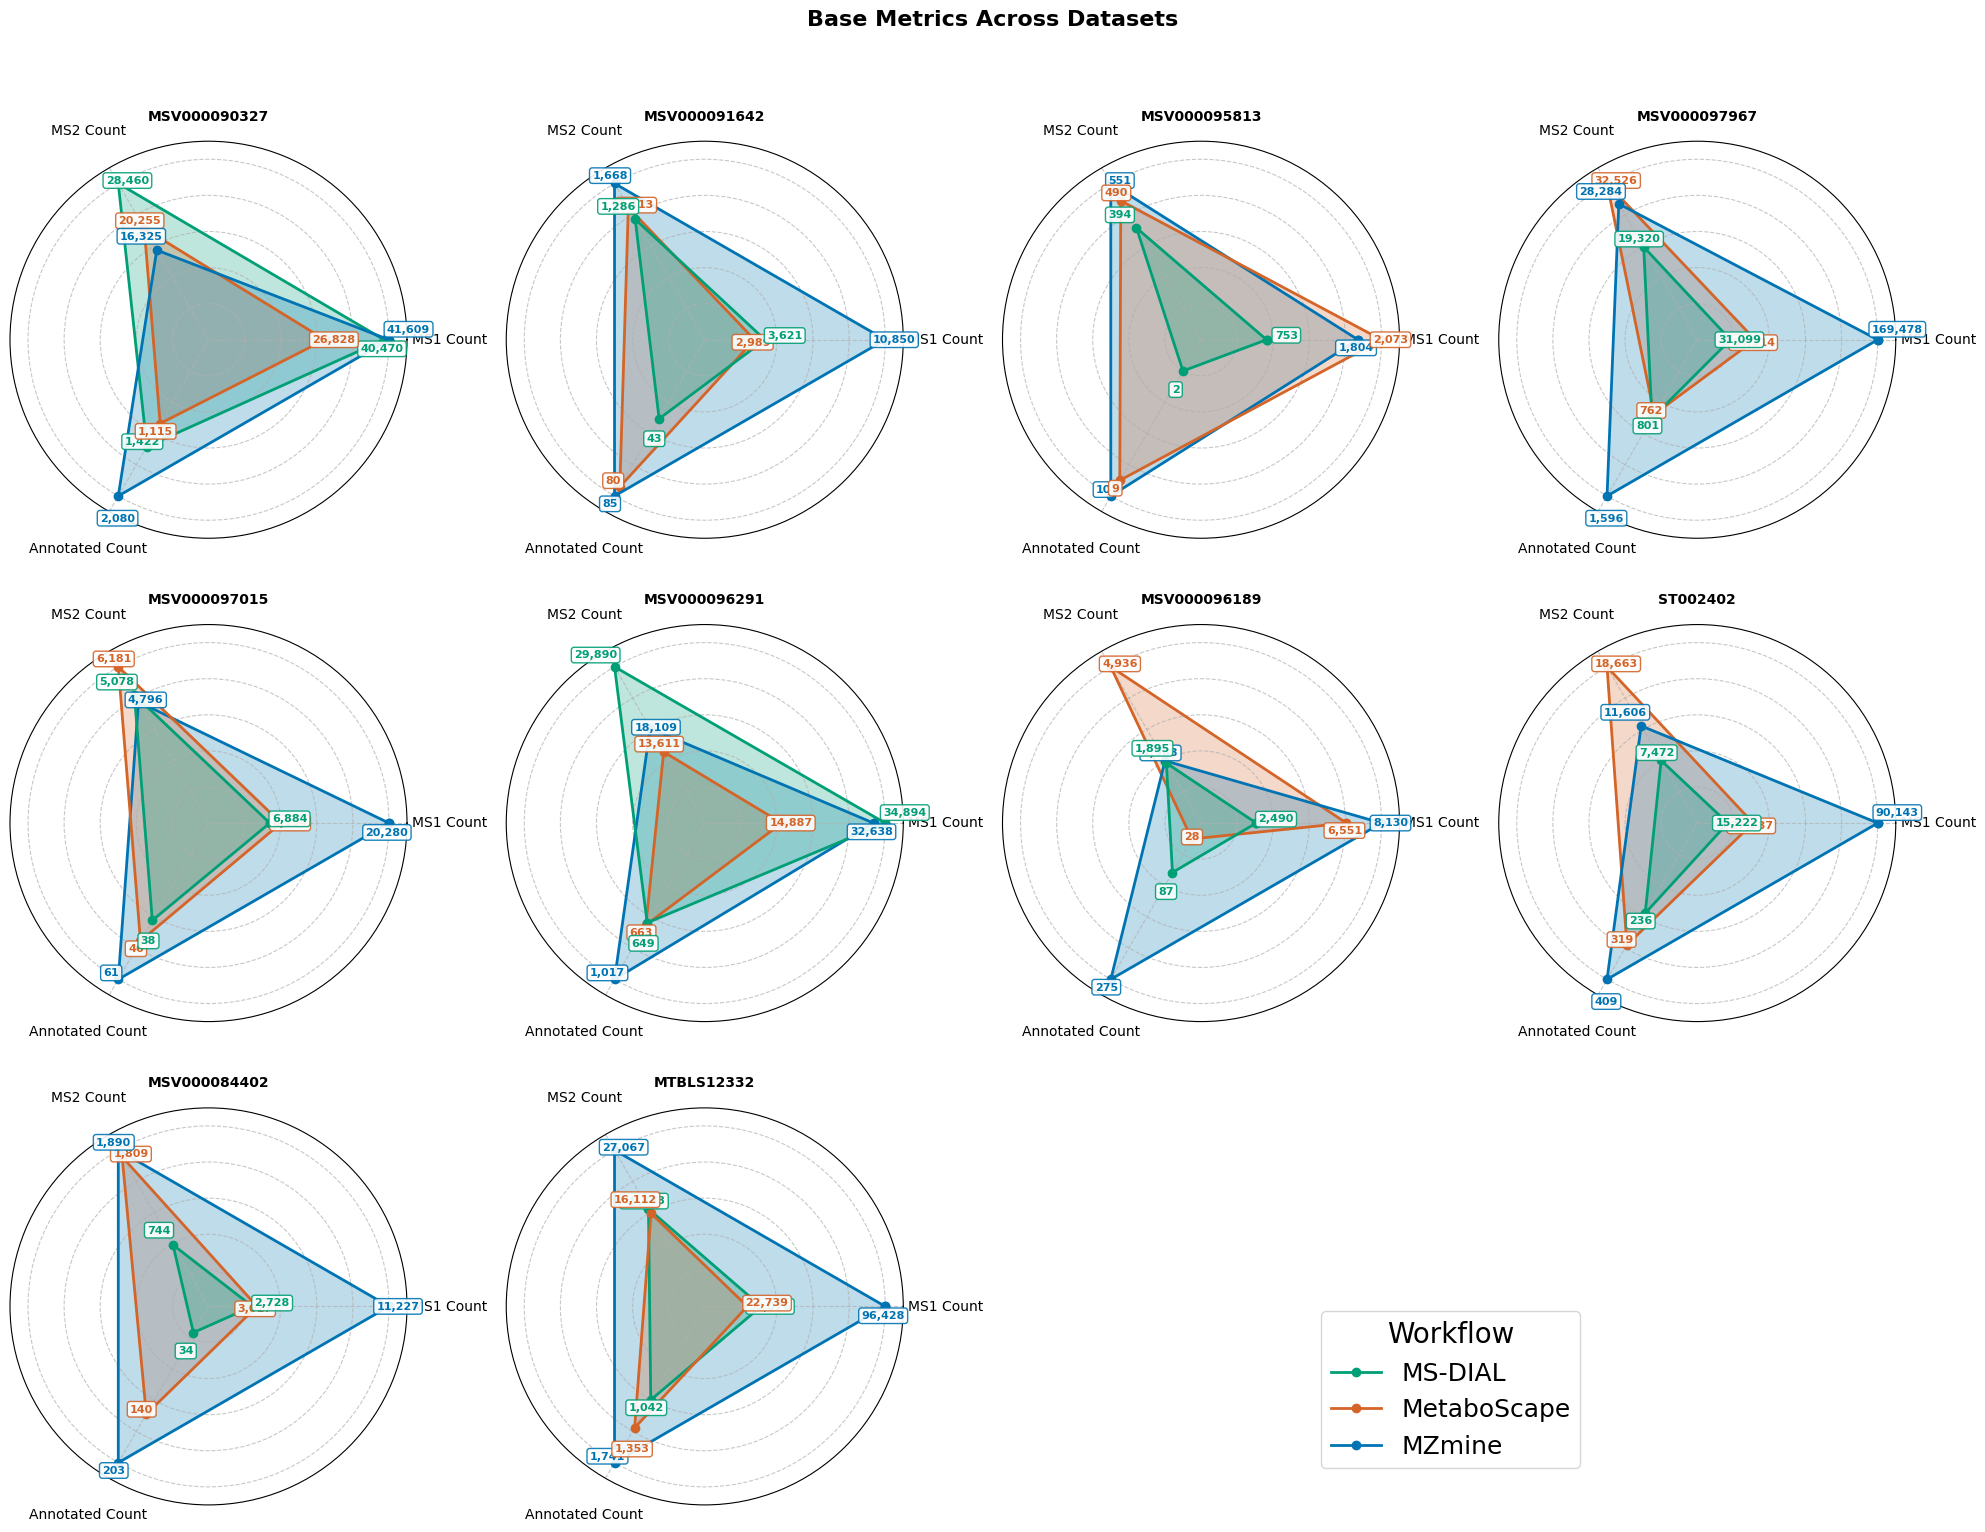

In [6]:
plot_individual_radars(
    input_dataset_directories,
    annotation_subfolder="annotated_spectral_entropy",
    title="Base Metrics Across Datasets",
    legend_position=(0.8, 0.1),
    save_path="../figures/supplementary_figure_3.png",
)

# Figure 2b: Create upset plots

In [7]:
plot_data = get_upset_plot_data(
    input_dataset_directories,
    similarity_threshold=0.7,
    annotation_subfolder="annotated_spectral_entropy",
)

Processing datasets: 100%|██████████| 10/10 [00:24<00:00,  2.41s/it]


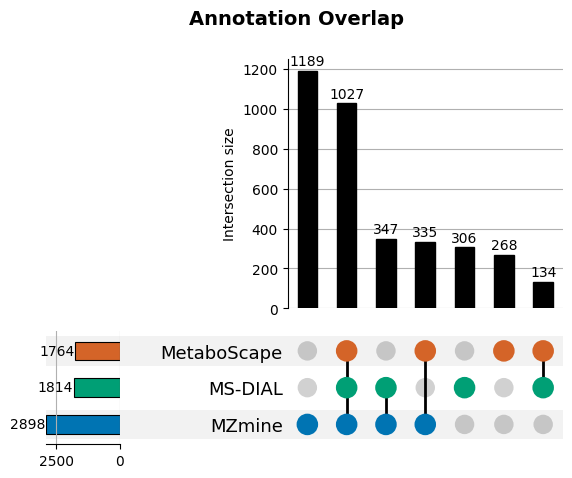

In [8]:
plot_upset_combined(
    combined_sets=plot_data,
    title="Annotation Overlap",
    figsize=(15, 6),
    save_path="../figures/figure_2b.png",
)

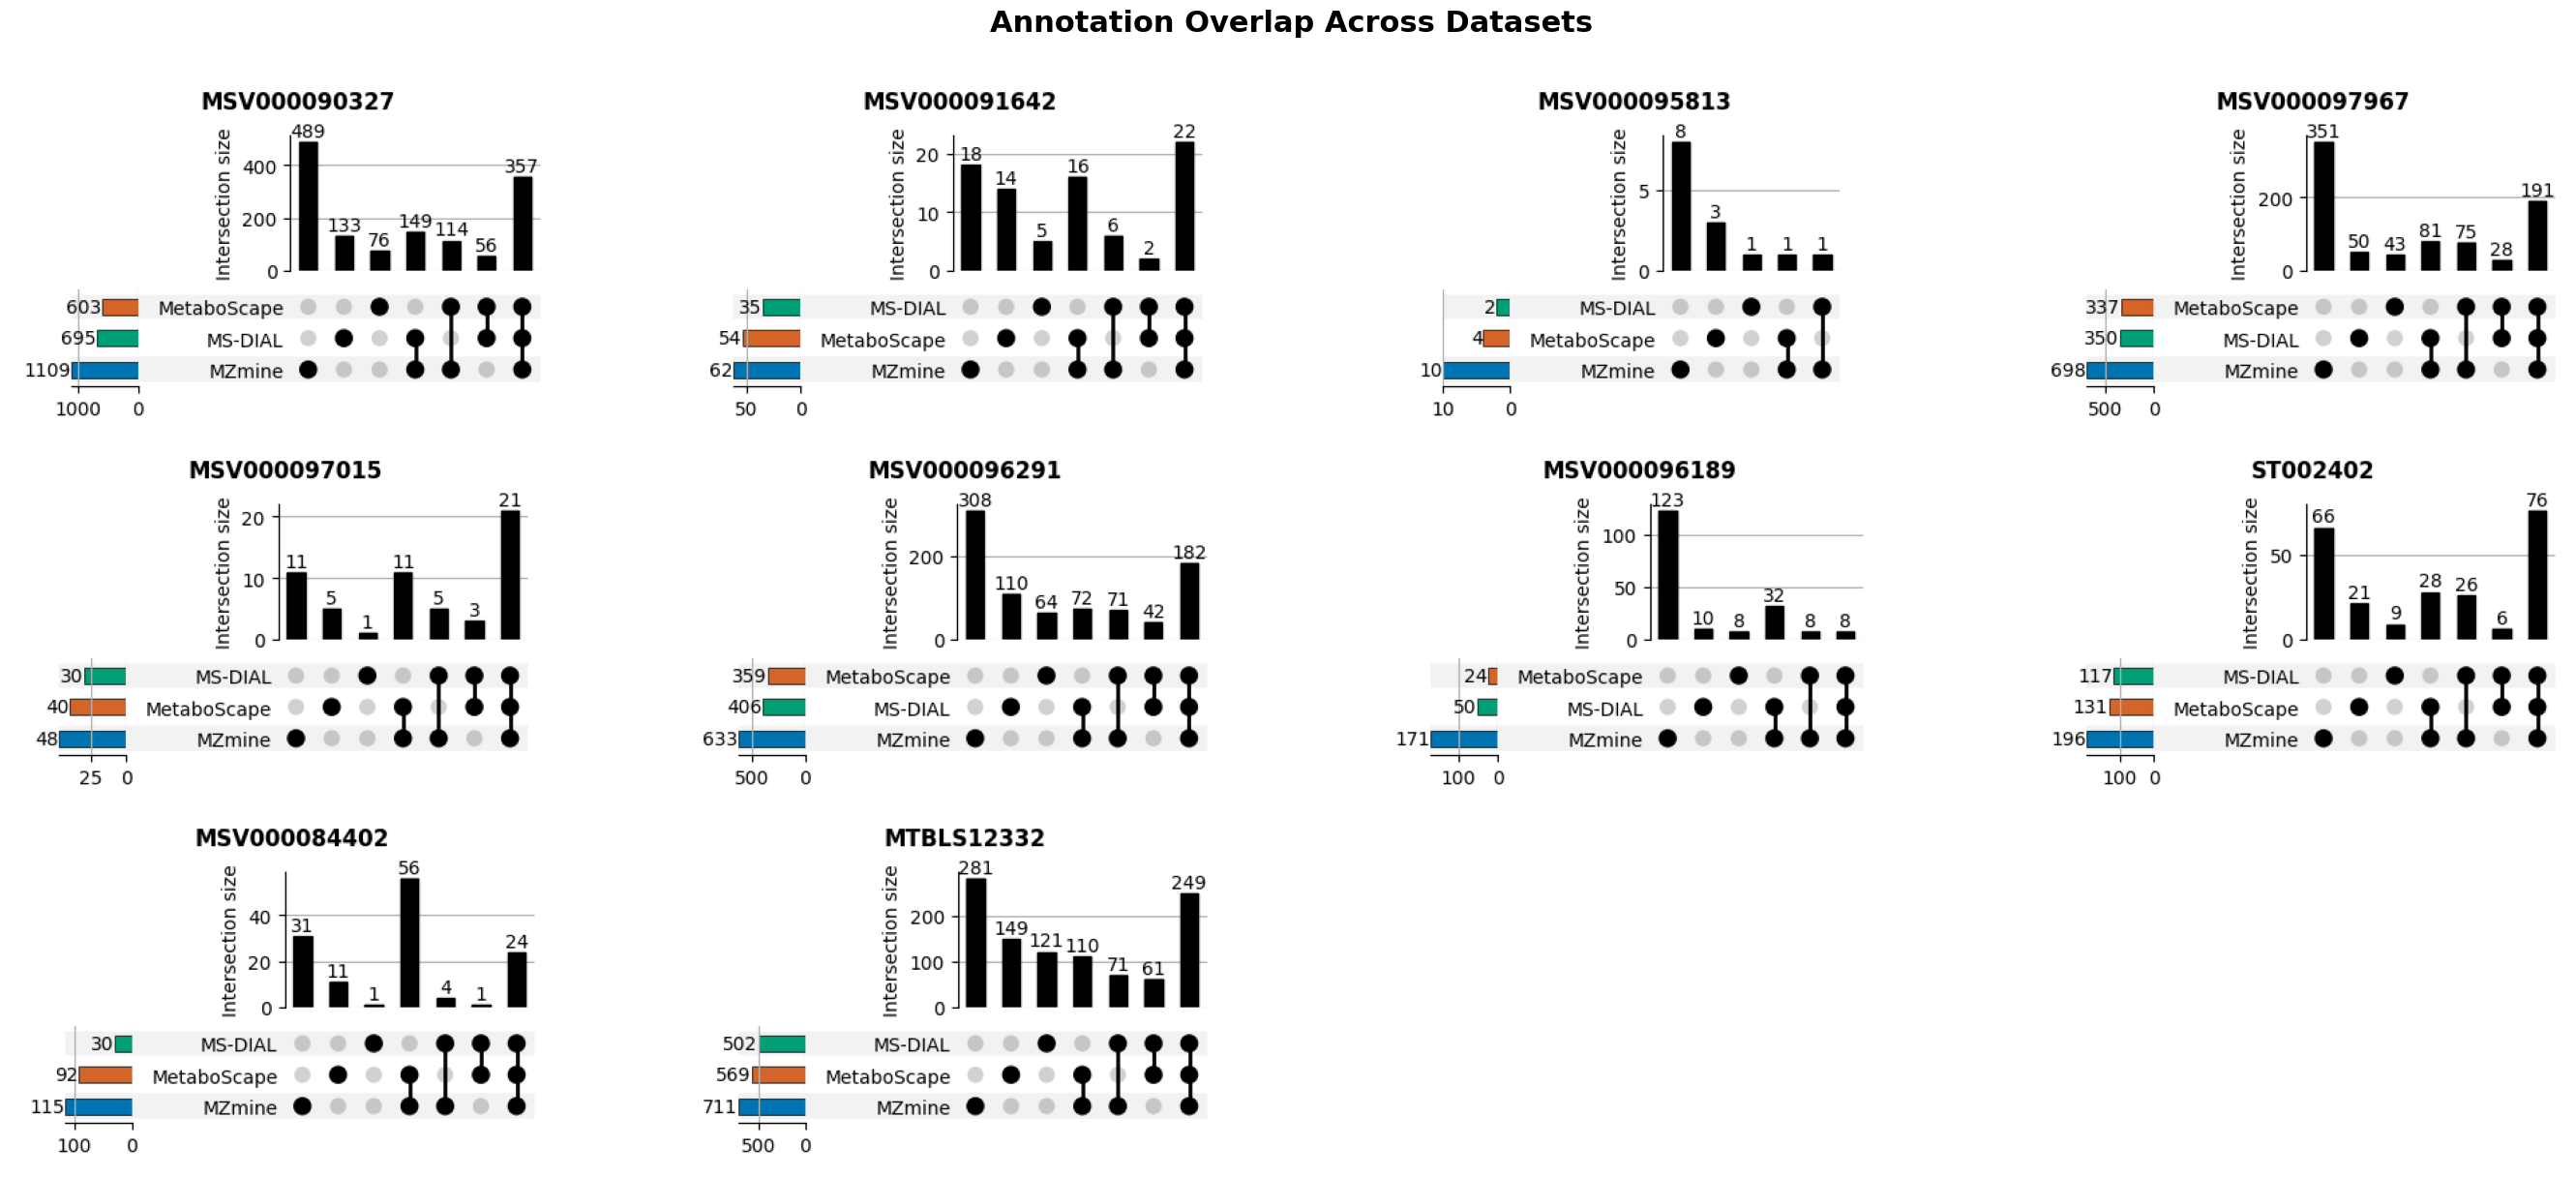

In [9]:
plot_individual_upset(
    input_dataset_directories,
    title="Annotation Overlap Across Datasets",
    similarity_threshold=0.7,
    save_path="../figures/supplementary_figure_4.png",
)

# Figure 2c: Precursor ion m/z distributions

In [10]:
all_feature_tables = load_all_feature_tables(
    input_directories=input_dataset_directories
)

100%|██████████| 10/10 [00:26<00:00,  2.67s/it]


Merging feature tables across datasets...


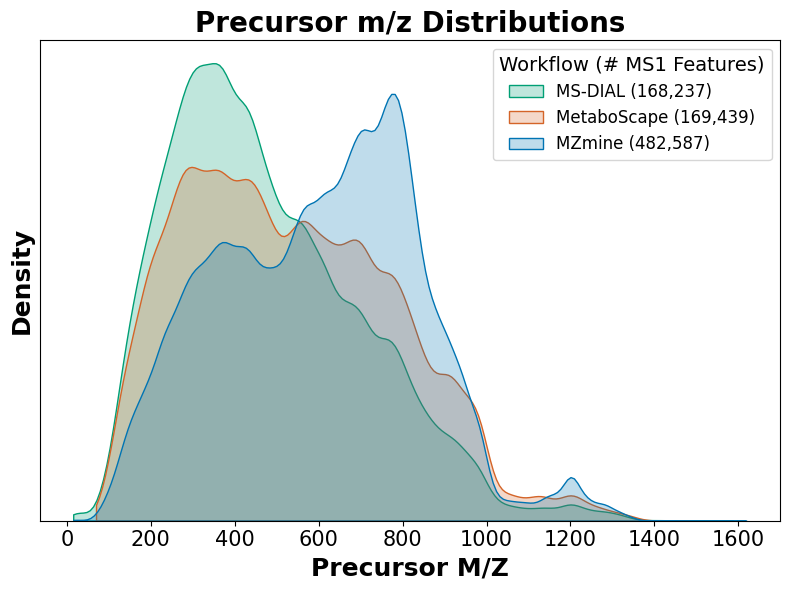

In [11]:
plot_precursor_distributions(
    all_feature_tables,
    figsize=(8, 6),
    title="Precursor m/z Distributions",
    save_path="../figures/figure_2c.png",
)

# Figure 2d: MS2 Quality

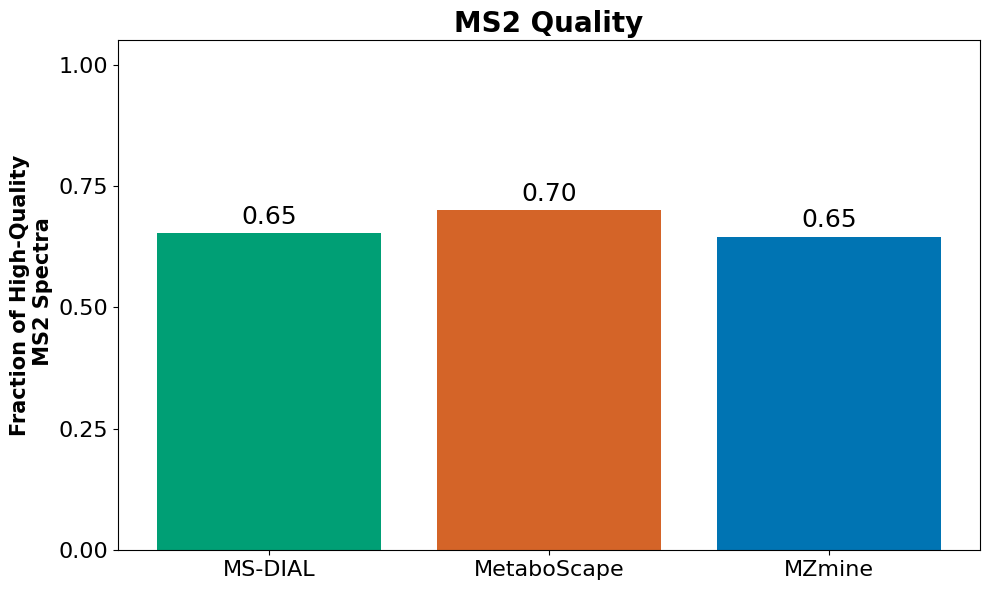

In [12]:
plot_ms2_quality(
    all_feature_tables,
    figsize=(10, 6),
    title="MS2 Quality",
    save_path="../figures/figure_2d.png",
)

# Figure 2e: MS2 fragment distribution

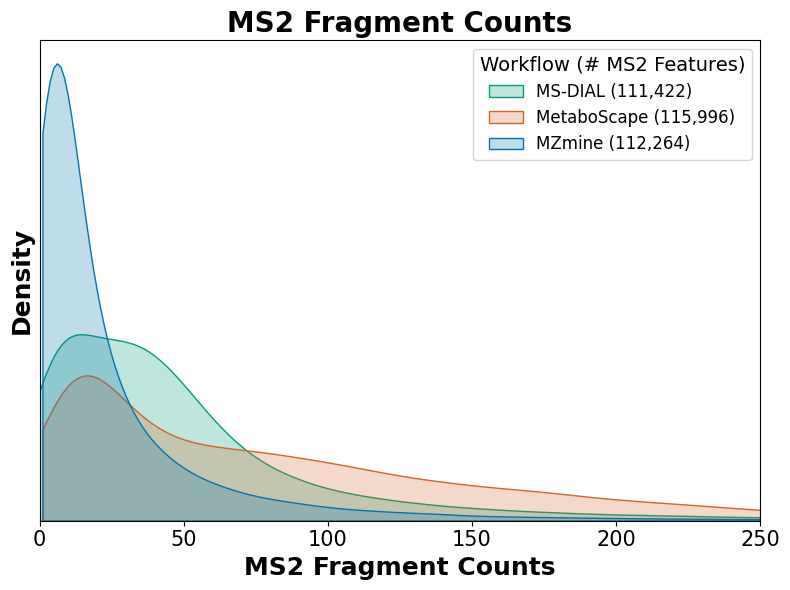

In [13]:
plot_peak_count_distribution(
    all_feature_tables,
    figsize=(8, 6),
    title="MS2 Fragment Counts",
    save_path="../figures/figure_2e.png",
)

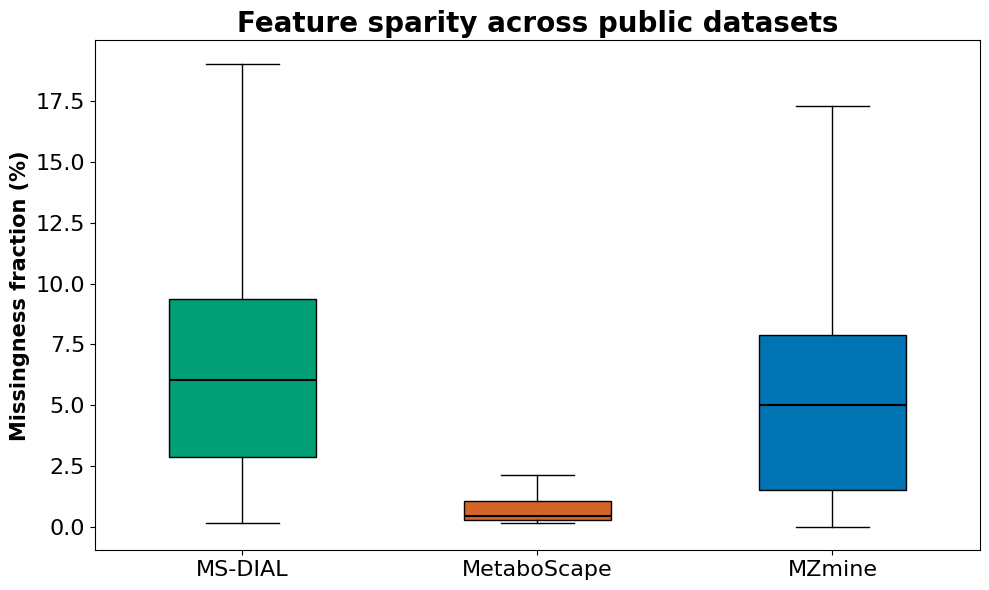

In [14]:
plot_sample_missingness(
    all_feature_tables,
    title="Feature sparity across public datasets",
    save_path="../figures/supplementary_figure_8.png",
)

# Figure 2f: Clique based metrics

In [15]:
cache_dir = "../data/cache"
os.makedirs(cache_dir, exist_ok=True)

clique_metrics = load_clique_metrics(
    cache_path=os.path.join(cache_dir, "clique_metrics_cache.json"),
    input_dataset_directories=input_dataset_directories,
)

Loaded clique metrics from cache: ../data/cache/clique_metrics_cache.json


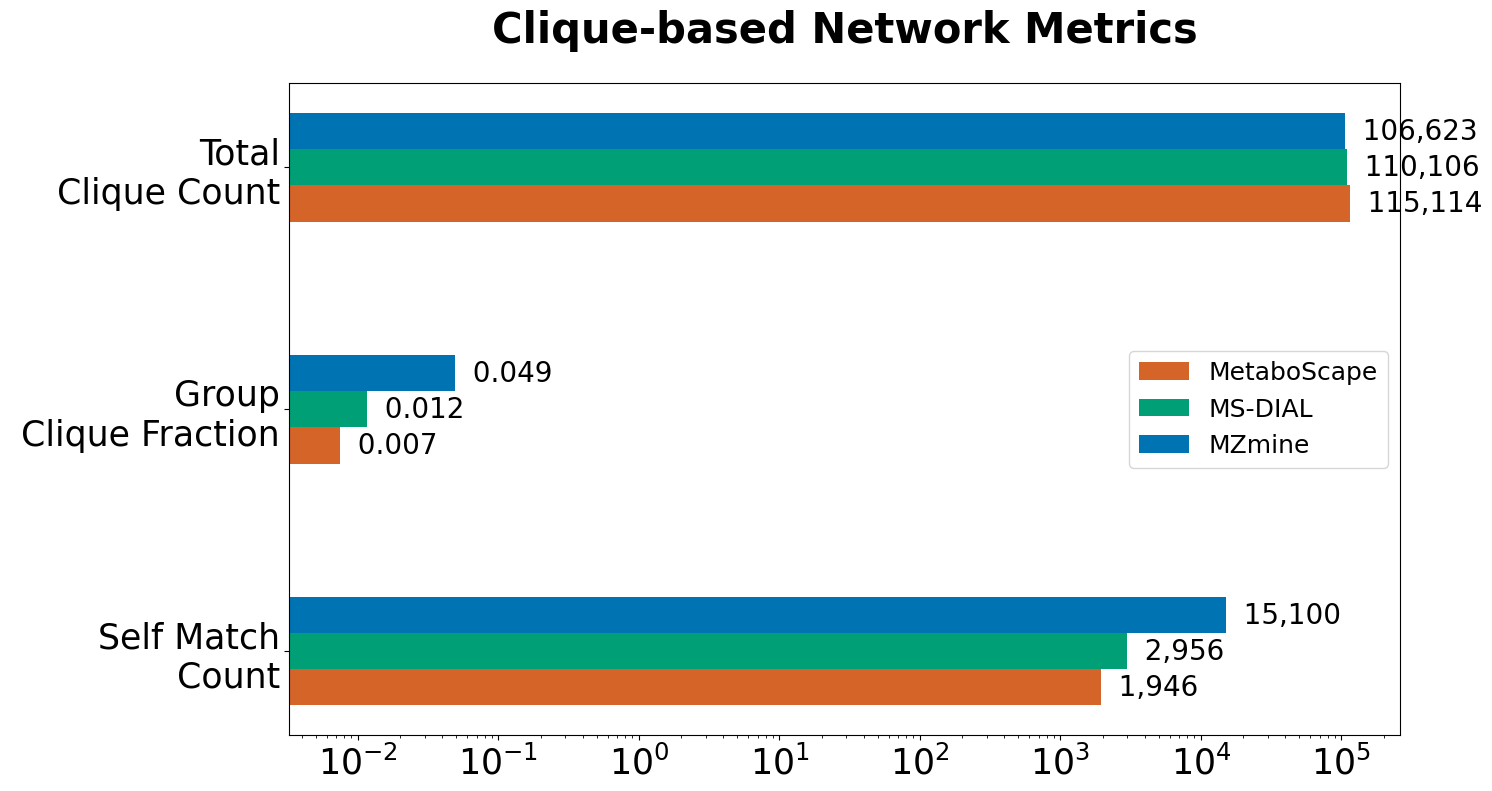

In [16]:
plot_clique_metrics(
    combined_metrics=clique_metrics,
    title="Clique-based Network Metrics",
    figsize=(15, 8),
    save_path="../figures/figure_2f.png",
)